# CNN classification on ESC-50

Mel spectrogram (128×128) → `CNNClassifier` (50 classes). Fold 5 = test, fold 4 = validation.

**Model:** ResNet-18 on mel (128×128). **Training:** SpecAugment, Mixup, Adam + weight decay, LR scheduler, early stopping. Best weights by `val_loss`; checkpoints by `val_acc`. Expect ~55–70% val acc (ESC-50 is hard with 50 classes).

**Prerequisites:** `uv sync`, ESC-50 in `ESC-50-master/`, then `uv run python -m src.data.make_dataset`.

In [1]:
import torch

from src import config
from src.data.dataloaders import get_dataloaders
from src.models import checkpoints
from src.models.cnn import CNNClassifier
from src.models.trainer import ModelTrainer
from src.visualization.visualize import plot_confusion_matrix, plot_training_history

TRAIN = True  # set False to load best checkpoint and only evaluate

torch.manual_seed(config.RANDOM_SEED)
device = config.get_device(require_cuda=True)
print(config.describe_device(device))
print(f"Manifest: {config.MANIFEST_PATH} (exists={config.MANIFEST_PATH.exists()})")
print("Saved versions:", checkpoints.list_versions("cnn"))

cuda:0 (NVIDIA GeForce RTX 4060 Ti, torch 2.12.0+cu126)
Manifest: C:\Users\ekurm\projects\nature-sound-generator\data\processed\manifest.json (exists=True)
Saved versions: [CheckpointInfo(version=1, run_id='20260519_165242', path=WindowsPath('C:/Users/ekurm/projects/nature-sound-generator/models/checkpoints/cnn/v001_20260519_165242/checkpoint.pt'), metrics={'train_loss': 32.30843138694763, 'train_acc': 0.0, 'val_loss': 4.59906005859375, 'val_acc': 0.125}, epoch=1), CheckpointInfo(version=2, run_id='20260519_165630', path=WindowsPath('C:/Users/ekurm/projects/nature-sound-generator/models/checkpoints/cnn/v002_20260519_165630/checkpoint.pt'), metrics={'train_loss': 4.375654414494832, 'train_acc': 0.05583333333333333, 'val_loss': 3.6702495288848875, 'val_acc': 0.075}, epoch=1), CheckpointInfo(version=3, run_id='20260519_165632', path=WindowsPath('C:/Users/ekurm/projects/nature-sound-generator/models/checkpoints/cnn/v003_20260519_165632/checkpoint.pt'), metrics={'train_loss': 3.530413519541

In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    "cnn", batch_size=config.BATCH_SIZE_CNN
)
print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Train batches: 38, Val: 13, Test: 13


In [3]:
model = CNNClassifier()
trainer = ModelTrainer(model, device=device, model_name="cnn")

if TRAIN:
    history = trainer.train_classifier(
        train_loader, val_loader, epochs=config.EPOCHS_CNN, save_checkpoints=True
    )
else:
    loaded = checkpoints.load_best("cnn", model)
    if loaded is None:
        raise FileNotFoundError("No checkpoint found. Set TRAIN=True first.")
    history = loaded.get("history", {})

Training on: cuda:0 (NVIDIA GeForce RTX 4060 Ti, torch 2.12.0+cu126)
Epoch 1/50 train_loss=4.3441 train_acc=0.0217 val_loss=3.8464 val_acc=0.0425
Saved checkpoint v016 (cnn) val_acc=0.0425 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\cnn\v016_20260519_170302\checkpoint.pt
  New best model (v016)
Epoch 2/50 train_loss=3.8445 train_acc=0.0458 val_loss=3.7617 val_acc=0.0825
Saved checkpoint v017 (cnn) val_acc=0.0825 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\cnn\v017_20260519_170303\checkpoint.pt
  New best model (v017)
Epoch 3/50 train_loss=3.7950 train_acc=0.0617 val_loss=3.6979 val_acc=0.0725
Epoch 4/50 train_loss=3.7670 train_acc=0.0517 val_loss=3.6525 val_acc=0.0700
Epoch 5/50 train_loss=3.7350 train_acc=0.0558 val_loss=3.5783 val_acc=0.1025
Saved checkpoint v018 (cnn) val_acc=0.1025 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\cnn\v018_20260519_170307\checkpoint.pt
  New best model (v018)
Epoch 6/50 train_loss

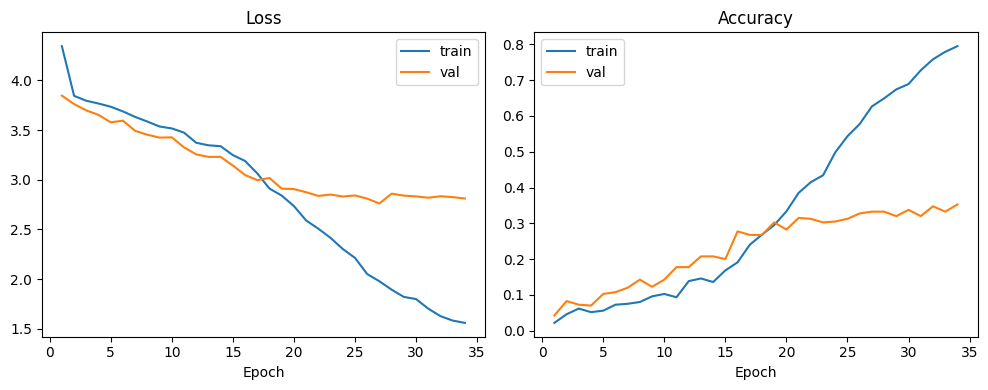

In [4]:
if history.get("train_loss"):
    plot_training_history(history)

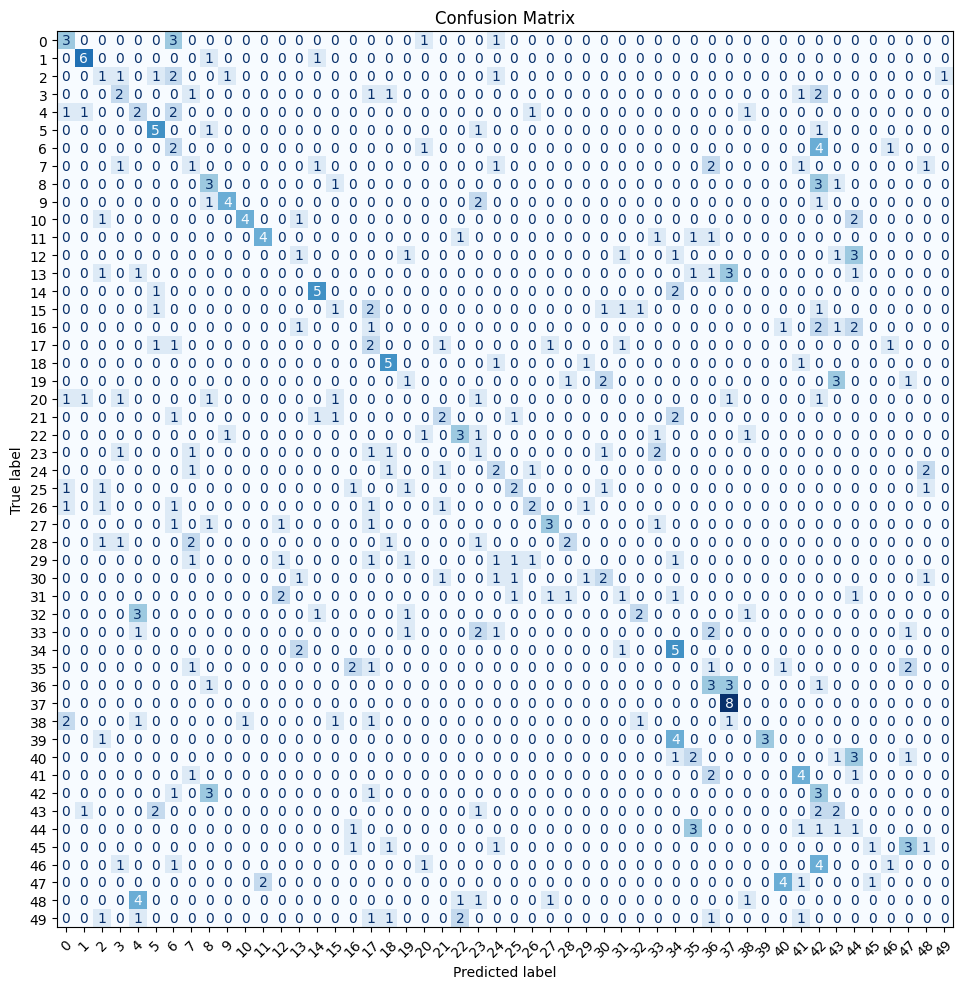

In [5]:
y_true, y_pred = trainer.predict_classifier(test_loader)
plot_confusion_matrix(y_true, y_pred)